### 🤖 Implement ReAct with LangGraph-What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
from langchain_community.tools import WikipediaQueryRun
from langchain_core.tools import Tool
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------
# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size= 500, chunk_overlap= 50)
chunks = splitter.split_documents(docs)

embedding = OllamaEmbeddings(model= "qwen3-embedding:8b")
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [5]:
retriever.invoke("what are autonomous agents")

[Document(id='13a3f7fb-7ad8-4334-9435-6904c2d44b05', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [6]:
def retriever_tool_func(query: str) -> str:
    """This Functions helps to retrieve context from vector database related to LM Powered Autonomous Agents"""
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [7]:
retriever_tool_func("what are autonomous agents")

📚 Using RAGRetriever tool


'Citation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\n[19] Joon Sung Park, et al. “Generative Agents: Interactive Simulacra of Human Behavior.” arXiv preprint arXiv:2304.03442 (2023).\n[20] AutoGPT. https://github.com/Significant-Gravitas/Auto-GPT\n[21] GPT-Engineer. https://github.com/AntonOsika/gpt-engineer\nLLM Powered Autonomous Agents | Lil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS

In [8]:
retriever_tool = Tool(
    name= "RAGRetriever",
    description= "Use this tool to fetch relevant knowledge base info",
    func= retriever_tool_func
)
print(retriever_tool.name)

RAGRetriever


In [9]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import Tool
import wikipedia

wiki_api = WikipediaAPIWrapper(wiki_client="nathchittajit8@gmail.com")

def safe_wiki_search(query: str) -> str:
    """Use this tool to search Wikipedia for general knowledge and summaries."""
    try:
        return wiki_api.run(query)
    except Exception as e:
        return f"Wikipedia search temporarily unavailable: {e}"

wiki_tool = Tool(
    name= "Wikipedia",
    description= "Use this tool to search Wikipedia for general knowledge and summaries.",
    func= safe_wiki_search
)

In [10]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()
os.environ["OLLAMA_API_KEY"] = str(os.getenv("OLLAMA_API_KEY"))
llm = init_chat_model("ollama:nemotron-3-nano:30b-cloud")

In [11]:
llm.invoke("Tell me about RAG!")

AIMessage(content='## Retrieval‑Augmented Generation (RAG) – A High‑Level Overview\n\n**RAG** is a design pattern that blends two core capabilities:\n\n| Component | What it does | Typical implementation |\n|-----------|--------------|------------------------|\n| **Retriever** | Looks up relevant pieces of external knowledge (documents, database rows, web snippets, etc.) for a given query. | Dense vector search (e.g., FAISS, Milvus), sparse keyword matching (BM25), hybrid approaches. |\n| **Generator** | Uses the retrieved information to produce a final output—usually a text answer, summary, code snippet, etc. | Large language model (LLM) that conditions on the retrieved passages (e.g., “prepend‑and‑extend”, “re‑rank‑and‑generate”). |\n\nIn short, **RAG = Retrieve → (possibly rank/augment) → Generate**, letting the model answer questions **beyond** what it memorized during its static pre‑training.\n\n---\n\n### 1️⃣ Why RAG Exists\n\n| Problem | RAG’s Solution |\n|---------|------------

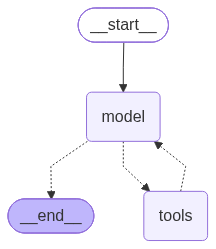

In [12]:
# ----------------------------
# 2. Define the Agent Node
# ----------------------------
from langchain.agents import create_agent

tools = [retriever_tool, safe_wiki_search]

## create the native Langgraph react agent
react_node = create_agent(model= llm, tools= tools)
react_node

In [13]:
# --------------------------
# 3. LangGraph Agent State
# --------------------------
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

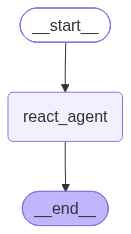

In [14]:
# --------------------------
# 4. Build LangGraph Graph
# --------------------------
builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [15]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state:AgentState = {"messages": [HumanMessage(content= user_query)]}
    result = graph.invoke(input= state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool
📚 Using RAGRetriever tool

✅ Final Answer:
 An **agent loop** refers to the iterative process by which an autonomous AI agent interacts with its environment to achieve a goal. This loop typically involves steps like **planning**, **action**, **observation**, **reflection**, and **refinement**. For example, an agent might break a complex task into smaller subgoals, execute actions, evaluate outcomes, and adjust strategies based on feedback. This cycle enables agents to adapt to dynamic environments and handle multi-step reasoning.

Regarding **autonomous agents**, while direct access to Wikipedia was temporarily unavailable, authoritative sources like Lil’Log (Lilian Weng’s blog) describe them as AI systems capable of **self-directed decision-making** and **goal-oriented behavior** without human intervention. Key traits include:  
- **Planning**: Decomposing tasks into manageable subgoals.  
- **Reflection**: Self-criticism and learning from mistakes.  
- **Act

### Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [16]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.tools import Tool
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_community.document_loaders import TextLoader

In [17]:
llm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, model='nemotron-3-nano:30b-cloud')

In [18]:
import certifi
import arxiv
### Generic function to create a retireval tool
from langchain_community.document_loaders import ArxivLoader

# 1. Provide CA bundle path to avoid Windows SSL verification errors
os.environ["SSL_CERT_FILE"] = certifi.where()
# 2. Fix the arXiv API endpoint to use HTTPS instead of HTTP (prevents 301 redirect errors)
arxiv.Client.query_url_format = "https://export.arxiv.org/api/query?{}"

def make_retriever_tool_from_text(file, name, desc):
    docs = TextLoader(file, encoding = "utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks, OllamaEmbeddings(model="qwen3-embedding:8b"))
    retriever = vs.as_retriever()

    def tool_func(query:str)->str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name= name, description= desc, func= tool_func)

wiki_api = WikipediaAPIWrapper(wiki_client="nathchittajit8@gmail.com")

def safe_wiki_search(query: str) -> str:
    """Use this tool to search Wikipedia for general knowledge and summaries."""
    try:
        return wiki_api.run(query)
    except Exception as e:
        return f"Wikipedia search temporarily unavailable: {e}"


# Wikipedia Tool
wiki_tool = Tool(
    name = "Wikipedia",
    description = "Use this tool to fetch general world knowledge from Wikipedia.",
    func = safe_wiki_search
)

# ArXiv Tool
def arxiv_search(query: str) -> str:
    print("🧪 Searching ArXiv...")
    try:
        loader = ArxivLoader(query= query, load_max_docs= 2, load_all_available_meta= True)
        results = loader.load()
        return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."
    except Exception as e:
        return f"ArXiv search temporarily unavailable: {e}"

arxiv_tool = Tool(
    name= "ArxivSearch",
    description= "Use this tool to fetch recent academic papers on technical topics.",
    func= arxiv_search
)

In [19]:
internal_tool_1 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalTechDocs",
    "Search internal tech documents for proprietary architecture and methods."
)
internal_tool_1

Tool(name='InternalTechDocs', description='Search internal tech documents for proprietary architecture and methods.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000001E28D9FD4E0>)

In [20]:
internal_tool_2 = make_retriever_tool_from_text(
    "sample_docs.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_2

Tool(name='InternalResearchNotes', description='Search internal research notes for experimental results and agent designs.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000001E28DB300E0>)

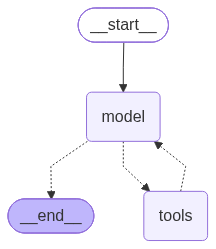

In [21]:
from langchain.agents import create_agent

tools=[wiki_tool, arxiv_tool, internal_tool_1, internal_tool_2]

# react_node = create_react_agent(llm, tools)
react_node = create_agent(model= llm, tools= tools)

react_node

In [22]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

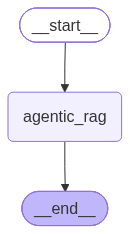

In [23]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph


In [24]:
query = "What do our research notes say about transformer variants, and what does arxiv suggest recently?"
import pymupdf

state:AgentState = {"messages": [HumanMessage(content= query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using tool: InternalResearchNotes
🧪 Searching ArXiv...

✅ Final Answer:
 **What the internal research notes say**

The excerpt you pulled from the internal research notes focuses on **agent‑level loops** rather than on transformer architectures per se. The key points are:

- **Agent loop** – a cycle of *thinking → acting → observing* that lets an AI agent continuously refine its behavior based on feedback.  
- **Real‑time adaptability** – the feedback loop is highlighted as essential for autonomous systems that must adjust on the fly.  
- **Benefits of agent‑based architectures** – they gain advantages when they incorporate memory, planning, and direct interaction with external tools.

In short, the notes emphasise how a continual “agent loop” can make autonomous agents more adaptive, but they do **not** delve into specific transformer variants or architectural details of Transformers.

---

**What the arXiv search reveals (recent work on transformer variants)**  

The arXiv query fo